In [1]:

%load_ext autoreload
%autoreload 2

import scanpy as sc
import pandas as pd
import numpy as np
import os
import gc
import seaborn as sns
import matplotlib.pyplot as plt


REAL_DATA_PATH = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_QCed_labelled_zoned.h5ad"
SIMULATION_DATA_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/only_depletion"

# Only iuse for extarciung cell types
TMP_SIM_ADATA = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/only_depletion/depleted_0.50_dorsal_matrix/depleted_0.50_dorsal_matrix.h5ad"

CONTRAST_VARIABLE = "case_control"
CONTRAST_VARIABLE_HEALTHY = "control"
CONTRAST_VARIABLE_DISEASED = "case"
DONOR_ID_VARIABLE = "donor_id"
CT_COL = "spn_type"

In [2]:
# creatin spn_type (Bennet)
spn_type_maping={
    "STRd D1 Matrix MSN": "dorsal_matrix",
    "STRd D2 Matrix MSN": "dorsal_matrix",

    "STRv D1 MSN": "ventral_matrix",
    "STRv D2 MSN": "ventral_matrix",
    "STRv D2 MSN": "ventral_matrix",

    "STRd D2 Striosome MSN": "patch",
    "STRd D1 Striosome MSN": "patch",
    "STRd D1 Striosome MSN": "patch",

    "STRd D2 StrioMat Hybrid MSN": "espn",
    "STR D1D2 Hybrid MSN": "espn",
    "STRv D1 NUDAP MSN": "espn",
}

In [3]:
sim_adata = sc.read_h5ad(TMP_SIM_ADATA, backed="r")
real_adata = sc.read_h5ad(REAL_DATA_PATH,  backed="r")

# Map cell types
real_adata.obs[CT_COL] = real_adata.obs["Group_name"].map(spn_type_maping)
real_adata.obs[CT_COL].value_counts()

# rename col
real_adata.obs = real_adata.obs.rename(columns={"condition": CONTRAST_VARIABLE})
real_adata.obs[CONTRAST_VARIABLE] = real_adata.obs[CONTRAST_VARIABLE].map({"XDP": CONTRAST_VARIABLE_DISEASED, "Control": CONTRAST_VARIABLE_HEALTHY})

# filter to same celltyps
sim_cts = sim_adata.obs[CT_COL].unique().to_list()
real_adata = real_adata[real_adata.obs[CT_COL].isin(sim_cts)].to_memory().copy()


/tmp/ipykernel_7974/846017959.py:13: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  sim_cts = sim_adata.obs[CT_COL].unique().to_list()


# LogFC NucSeq Real Vs Only-depletion Simulation

In [4]:
def calc_logFC(adata, CONTRAST_VARIABLE, CONTRAST_VARIABLE_HEALTHY, CONTRAST_VARIABLE_DISEASED, layer="counts", logFC_name="logFC"):

    print("\t\tNormalising...")
    if layer is not None and layer in adata.layers:
        adata.X = adata.layers[layer].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)  

    print("\t\tCalculating logFC")
    healthy = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_HEALTHY]
    diseased = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED]

    # Mean expression per group
    mean_healthy = np.array(healthy.X.mean(axis=0)).flatten()
    mean_diseased = np.array(diseased.X.mean(axis=0)).flatten()

    # LogFC = log(diseased) - log(healthy) (already in log space, so just subtract)
    logFC = mean_diseased - mean_healthy

    return pd.DataFrame({logFC_name: logFC}, index=adata.var_names)

		Normalising...
		Calculating logFC


<Axes: ylabel='Frequency'>

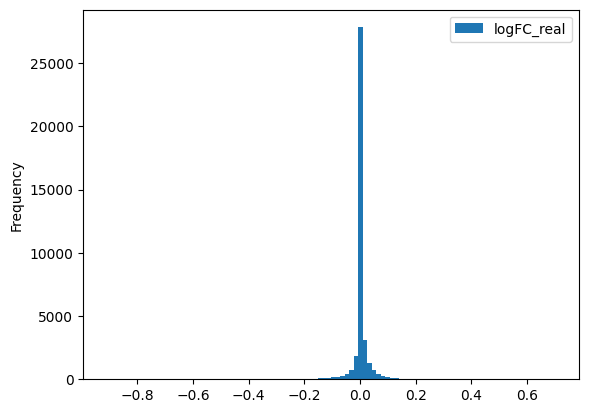

In [5]:
# Calculate logFC in real data
logFC_real = calc_logFC(real_adata, CONTRAST_VARIABLE, CONTRAST_VARIABLE_HEALTHY, CONTRAST_VARIABLE_DISEASED, layer="counts", logFC_name="logFC_real")
logFC_real.plot(kind="hist", bins=100)

In [6]:
# Claulte logFC of simualtions

all_logFC = []
for dataset in sorted(os.listdir(SIMULATION_DATA_FOLDER)):
    dataset_path_h5ad = os.path.join(SIMULATION_DATA_FOLDER, dataset, f"{dataset}.h5ad")
    sim_dep = sc.read_h5ad(dataset_path_h5ad)
    logFC_sim_dep = calc_logFC(sim_dep, CONTRAST_VARIABLE, CONTRAST_VARIABLE_HEALTHY, 
                                CONTRAST_VARIABLE_DISEASED, layer="counts", 
                                logFC_name=f"logFC_{dataset}")
    logFC_sim_dep = logFC_sim_dep.merge(logFC_real, how="inner", 
                                        right_index=True, left_index=True)
    all_logFC.append(logFC_sim_dep)

		Normalising...
		Calculating logFC
		Normalising...
		Calculating logFC
		Normalising...
		Calculating logFC
		Normalising...
		Calculating logFC
		Normalising...
		Calculating logFC
		Normalising...
		Calculating logFC


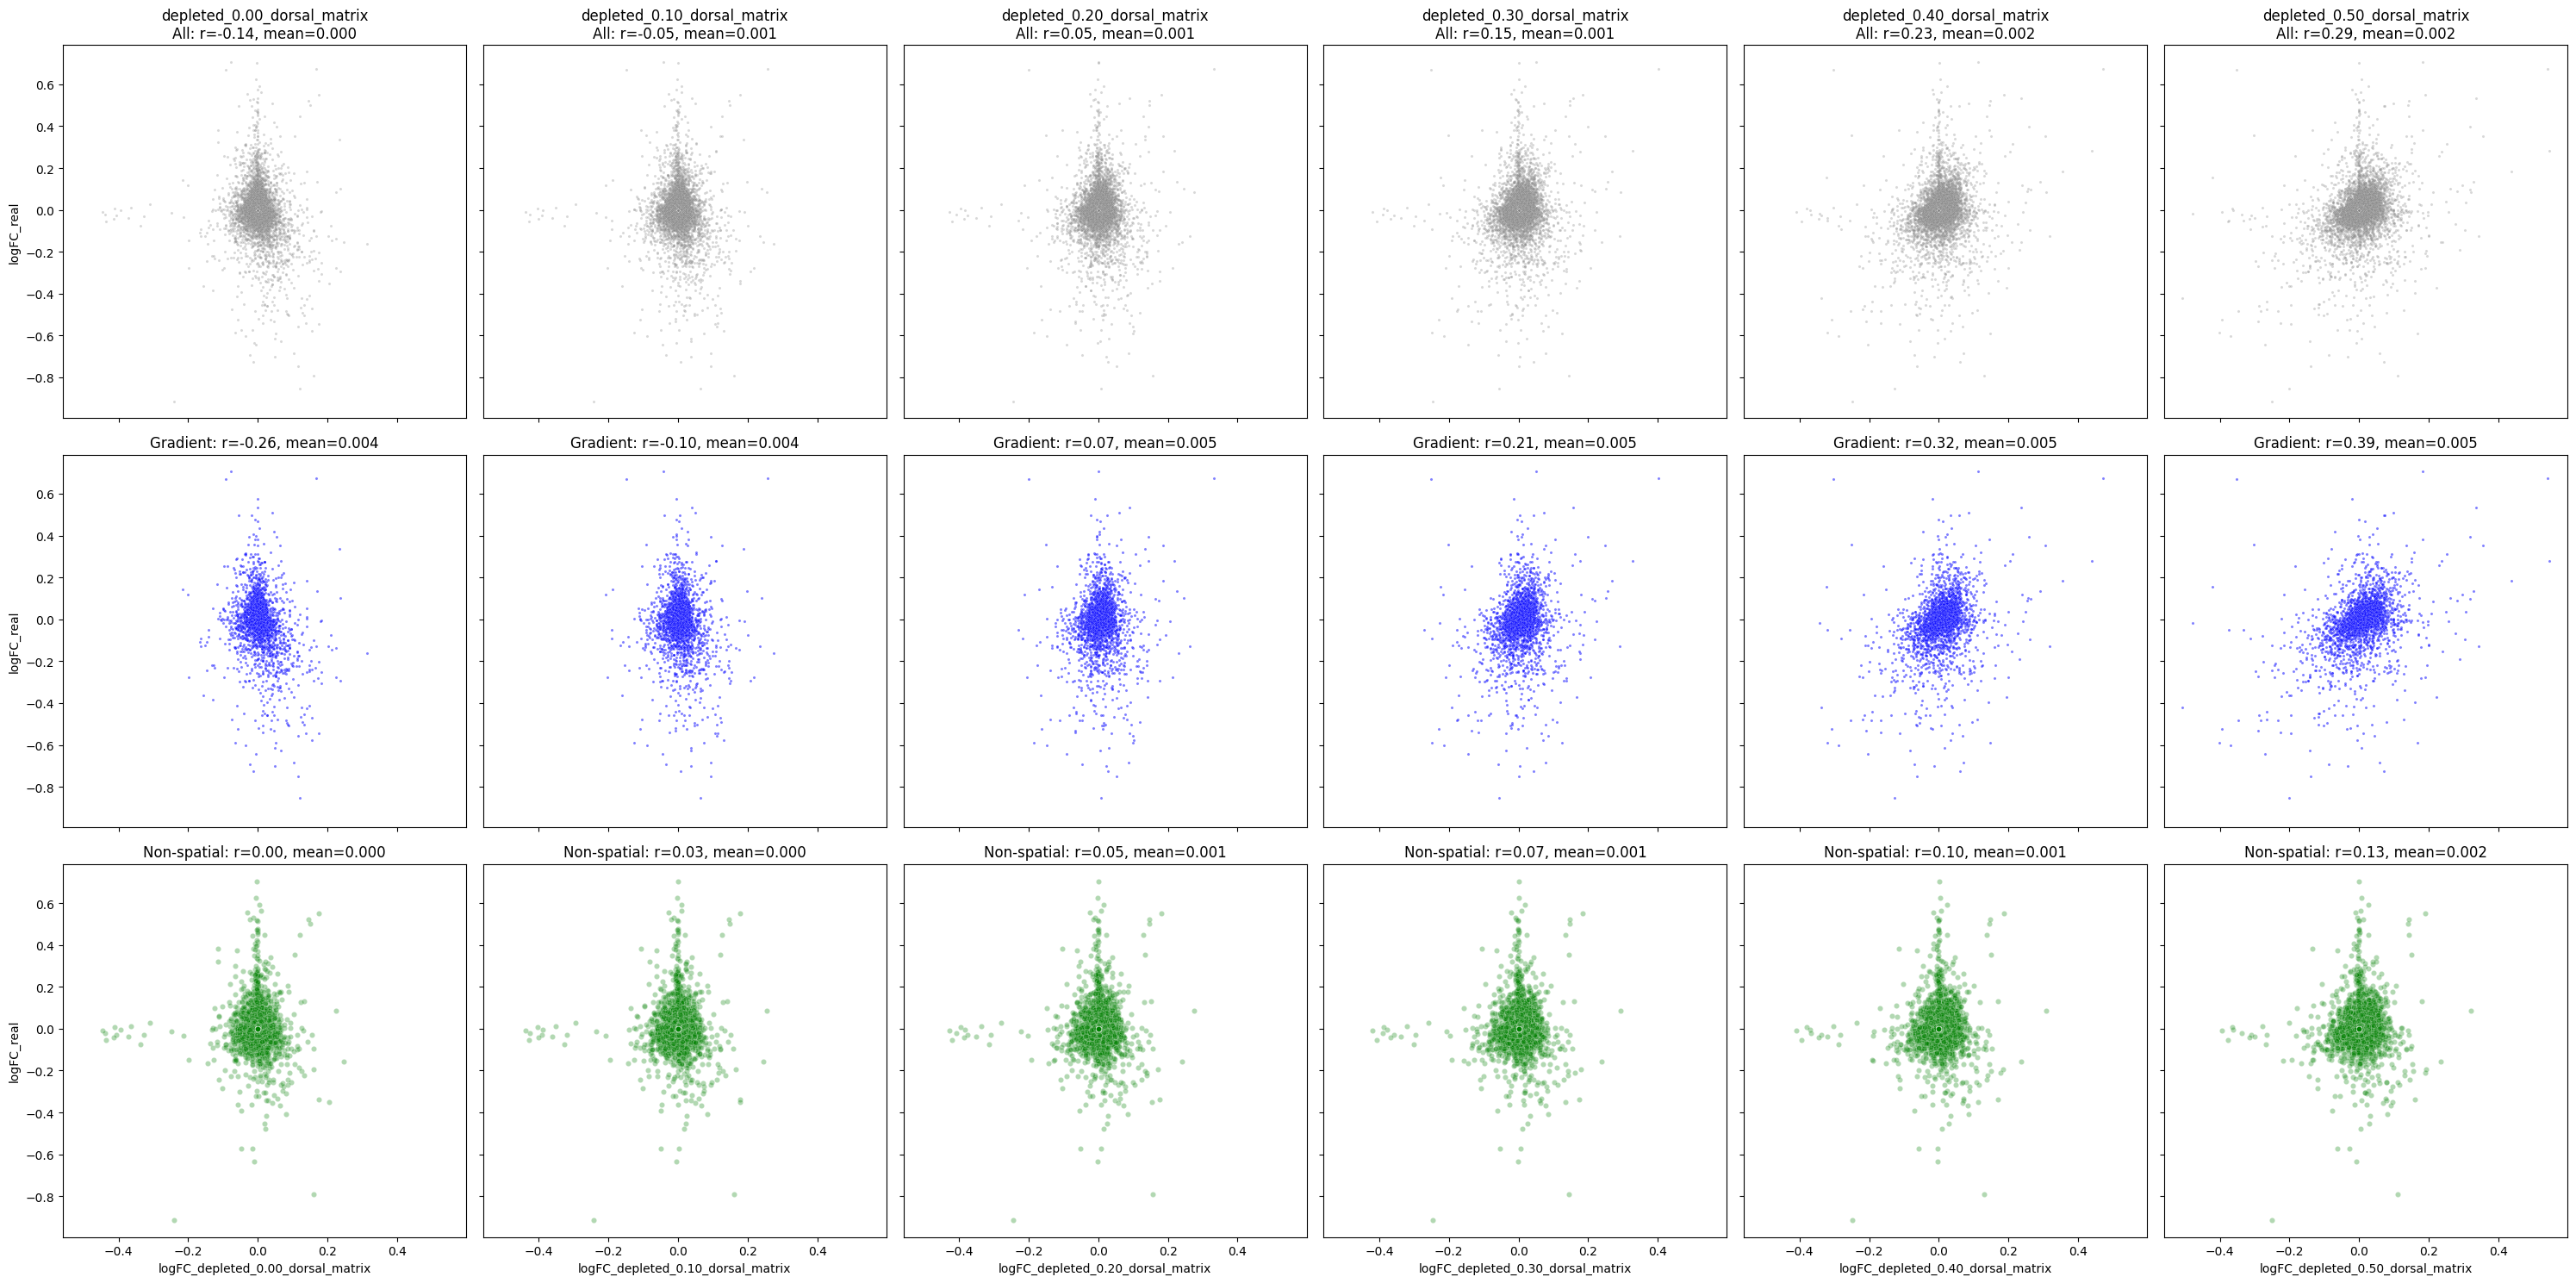


SUMMARY RESULTS
                    dataset  r_all_genes  mean_all_genes  r_gradient_genes  mean_gradient_genes  n_gradient_genes  r_nonspatial_genes  mean_nonspatial_genes  n_nonspatial_genes
depleted_0.00_dorsal_matrix    -0.139345        0.000468         -0.258781             0.004344              3461            0.004157               0.000048               31903
depleted_0.10_dorsal_matrix    -0.045148        0.000769         -0.104592             0.004456              3461            0.027961               0.000369               31903
depleted_0.20_dorsal_matrix     0.052149        0.001059          0.065492             0.004585              3461            0.050245               0.000676               31903
depleted_0.30_dorsal_matrix     0.145770        0.001375          0.213588             0.004739              3461            0.074246               0.001010               31903
depleted_0.40_dorsal_matrix     0.225518        0.001688          0.319251             0.004808   

In [22]:
grad_df = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv") #pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined_corr>0.1.csv")
grad_df = grad_df[(grad_df.combined_p <= 0.05) & (np.abs(grad_df.mean_spearman) >= 0.05)]


gradient_genes = grad_df.gene.unique().tolist()

# Initialize list to collect results
datasets=sorted(os.listdir(SIMULATION_DATA_FOLDER))
results = []

# Create figure with 3 rows and one column per dataset
fig, axes = plt.subplots(3, len(datasets), figsize=(5*len(datasets), 15), 
                         sharex=True, sharey=True)


# Loop through each dataset
for i, (dataset, logFC_sim_dep) in enumerate(zip(datasets, all_logFC)):
    
    # Row 0: All genes
    sns.scatterplot(data=logFC_sim_dep, x=f"logFC_{dataset}", y="logFC_real", 
                    ax=axes[0, i], s=5, alpha=0.3, color='gray')
    
    r_all = np.corrcoef(logFC_sim_dep[f"logFC_{dataset}"], logFC_sim_dep["logFC_real"])[0,1]
    mean_all = logFC_sim_dep[f"logFC_{dataset}"].mean()
    axes[0, i].set_title(f"{dataset}\nAll: r={r_all:.2f}, mean={mean_all:.3f}")
    
    # Row 1: Only gradient genes (spatial genes)
    logFC_gradient = logFC_sim_dep[logFC_sim_dep.index.isin(gradient_genes)]
    sns.scatterplot(data=logFC_gradient, x=f"logFC_{dataset}", y="logFC_real", 
                    ax=axes[1, i], s=5, alpha=0.5, color='blue')
    
    r_grad = np.corrcoef(logFC_gradient[f"logFC_{dataset}"], logFC_gradient["logFC_real"])[0,1]
    mean_grad = logFC_gradient[f"logFC_{dataset}"].mean()
    axes[1, i].set_title(f"Gradient: r={r_grad:.2f}, mean={mean_grad:.3f}")
    
    # Row 2: Only non-spatial genes (genes NOT in gradient list)
    logFC_nonspatial = logFC_sim_dep[~logFC_sim_dep.index.isin(gradient_genes)]
    sns.scatterplot(data=logFC_nonspatial, x=f"logFC_{dataset}", y="logFC_real", 
                    ax=axes[2, i], s=20, alpha=0.3, color='green')
    
    r_nonspatial = np.corrcoef(logFC_nonspatial[f"logFC_{dataset}"], logFC_nonspatial["logFC_real"])[0,1]
    mean_nonspatial = logFC_nonspatial[f"logFC_{dataset}"].mean()
    axes[2, i].set_title(f"Non-spatial: r={r_nonspatial:.2f}, mean={mean_nonspatial:.3f}")
    
    # Store results in dictionary
    results.append({
        'dataset': dataset,
        'r_all_genes': r_all,
        'mean_all_genes': mean_all,
        'r_gradient_genes': r_grad,
        'mean_gradient_genes': mean_grad,
        'n_gradient_genes': len(logFC_gradient),
        'r_nonspatial_genes': r_nonspatial,
        'mean_nonspatial_genes': mean_nonspatial,
        'n_nonspatial_genes': len(logFC_nonspatial)
    })

plt.tight_layout()
plt.show()

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("SUMMARY RESULTS")
print("="*80)
print(results_df.to_string(index=False))

In [18]:
logFC_nonspatial[logFC_nonspatial["logFC_depleted_0.50_dorsal_matrix"] <= -0.2]
#logFC_nonspatial[logFC_nonspatial["logFC_real"] >= 0.3]

,logFC_depleted_0.50_dorsal_matrix,logFC_real
APPAT,-0.217660,-0.153055
DHFR,-0.361181,-0.003117
MT-ATP6,-0.375814,-0.053711
MT-ATP8,-0.364245,0.008192
MT-CO1,-0.202069,0.027581
MT-CO2,-0.310708,-0.027601
MT-CO3,-0.336590,-0.022727
MT-CYB,-0.314087,-0.043697
MT-ND1,-0.264610,-0.028465
MT-ND2,-0.267642,-0.076365


---
---
---

In [44]:
logFC_sim_dep = logFC_sim_dep.merge(logFC_real, how="inner", right_index=True, left_index=True)


r = np.corrcoef(logFC_sim_dep[f'logFC_{dataset}'], logFC_sim_dep['logFC_real'])[0,1]
print(f"{dataset}: r = {r:.3f}")

depleted_0.50_dorsal_matrix: r = 0.290


In [43]:
    print("\tReading h5ad...")
    sim_dep = sc.read_h5ad(dataset_path_h5ad)

    print("\tCalc logFC")
    logFC_sim_dep = calc_logFC(sim_dep, CONTRAST_VARIABLE, CONTRAST_VARIABLE_HEALTHY, CONTRAST_VARIABLE_DISEASED, layer="counts", logFC_name=f"logFC_{dataset}")


	Reading h5ad...


	Calc logFC
Normalising...
Calculating logFC


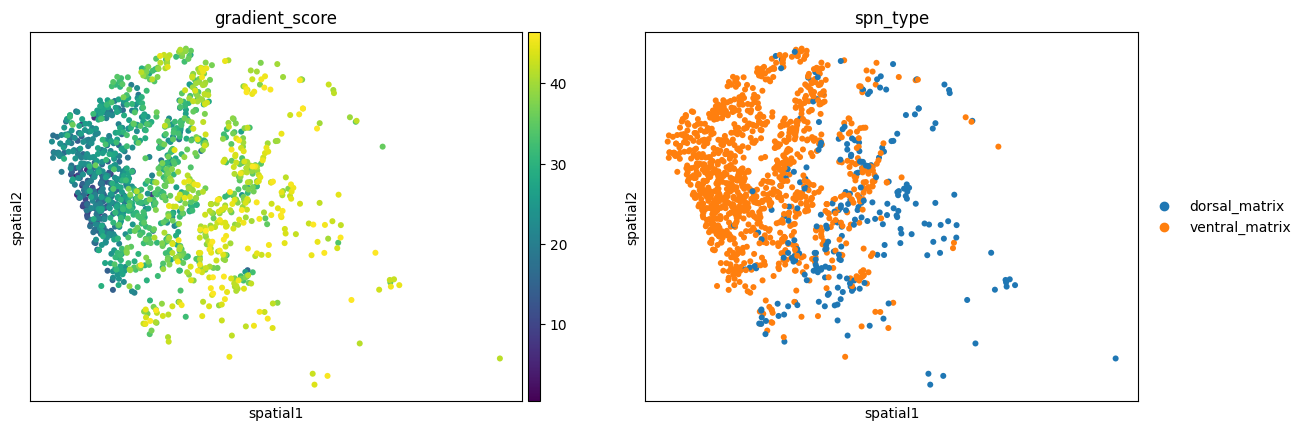

In [45]:
sample_id = "MS913848" #adata_pert_tmp.obs[adata_pert_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED][DONOR_ID_VARIABLE].unique()[0]
adata_s = sim_dep[sim_dep.obs[DONOR_ID_VARIABLE] == sample_id].to_memory().copy()
adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type"])
del adata_s